**MobileNetV2 Hybrid / PCA-Hybrid**

* FH/CH/AB ROI → MobileNetV2 embeddings
* Classical features + Embeddings concat → SVM
* PCA(64/128/256) sweep

Compare:
* Full Hybrid (MobileNetV2)
* PCA Hybrid (MobileNetV2)
* EfficientNet results

**MobileNetV2 Hybrid + PCA-Hybrid V1**

* ✅ Dataset load/label
* ✅ ROI crop (FH/CH/AB)
* ✅ classical feature extraction
* ✅ MobileNetV2 embeddings extract
* ✅ Full Hybrid (no PCA): CV AUC + Test AUC + ROC + PR + Confusion matrix
* ✅ PCA sweep (64/128/256): CV AUC plot + explained variance plot
* ✅ Best PCA: Test evaluation + Youden threshold + Confusion matrix
* ✅ Calibration curve + Brier
* ✅ Bootstrap AUC 95% CI (best model)
* ✅ Plots: ROC, PR, calibration, probability hist, AUC bootstrap hist
* ✅ Export models (SVM + PCA + imputer + metadata)

In [1]:
!pip -q install opencv-python numpy pandas matplotlib seaborn scikit-learn scipy tqdm tensorflow joblib

import os, glob, random
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
import joblib

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Seed + Dataset path + Load + Labeling**

In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

sayem = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"

img_exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")
all_imgs = []
for ext in img_exts:
    all_imgs += glob.glob(os.path.join(sayem, "**", ext), recursive=True)

def infer_label_from_path(p):
    lp = p.lower()
    pos_keys = ["jaundice","icteric","positive","pos","case","patient","affected","yellow"]
    neg_keys = ["normal","control","negative","neg","healthy","non"]
    if any(k in lp for k in pos_keys): return 1
    if any(k in lp for k in neg_keys): return 0
    return None

pairs = [(p, infer_label_from_path(p)) for p in all_imgs]
pairs = [(p,l) for p,l in pairs if l is not None]

print("Total labeled:", len(pairs))
print("Class counts (0,1):", np.bincount([l for _,l in pairs]))
print("Example:", pairs[:3])

Total labeled: 760
Class counts (0,1): [560 200]
Example: [('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1000).jpg', 0), ('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1103).jpg', 0), ('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1078).jpg', 0)]


**ROI functions (FH/CH/AB)**

In [4]:
def extract_forehead_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.10*h); y2 = int(0.40*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

def extract_chest_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.40*h); y2 = int(0.80*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

def extract_abdomen_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.60*h); y2 = int(0.92*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

**Preprocess + Skin mask + Classical features**

In [5]:
def gray_world_white_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img)
    mb, mg, mr = np.mean(b), np.mean(g), np.mean(r)
    m = (mb + mg + mr) / 3.0
    b = b * (m / (mb + 1e-6))
    g = g * (m / (mg + 1e-6))
    r = r * (m / (mr + 1e-6))
    out = cv2.merge([b,g,r])
    return np.clip(out, 0, 255).astype(np.uint8)

def normalize_clahe_lab(roi_bgr, clip=2.5):
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8,8))
    L2 = clahe.apply(L)
    lab2 = cv2.merge([L2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

def preprocess_roi(roi_bgr):
    roi_bgr = gray_world_white_balance(roi_bgr)
    roi_bgr = normalize_clahe_lab(roi_bgr, clip=2.5)
    return roi_bgr

def skin_mask_hsv(roi_bgr):
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)
    k = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)
    return mask

def masked_stats(channel, mask):
    vals = channel[mask==255].astype(np.float32)
    if vals.size < 30:
        return (np.nan,)*6
    return (
        float(np.mean(vals)),
        float(np.std(vals)),
        float(np.median(vals)),
        float(skew(vals)),
        float(kurtosis(vals)),
        float(np.percentile(vals, 90))
    )

def extract_classical_features(roi_bgr):
    roi_bgr = preprocess_roi(roi_bgr)
    mask = skin_mask_hsv(roi_bgr)
    if np.sum(mask==255) < 200:
        mask = np.ones(roi_bgr.shape[:2], dtype=np.uint8)*255

    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    R = roi_rgb[:,:,0]; G = roi_rgb[:,:,1]; B = roi_rgb[:,:,2]

    Rm, Rs, _, _, _, R90 = masked_stats(R, mask)
    Gm, Gs, _, _, _, G90 = masked_stats(G, mask)
    Bm, Bs, _, _, _, B90 = masked_stats(B, mask)

    ygi = float((Rm + Gm) / (Bm + 1e-6))
    r_over_b = float(Rm / (Bm + 1e-6))
    g_over_b = float(Gm / (Bm + 1e-6))

    denom = (Rm + Gm + Bm + 1e-6)
    r_ch = float(Rm / denom); g_ch = float(Gm / denom); b_ch = float(Bm / denom)

    hsv = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
    H = hsv[:,:,0]; S = hsv[:,:,1]; V = hsv[:,:,2]
    Hm, _, _, _, _, _ = masked_stats(H, mask)
    Sm, _, _, _, _, _ = masked_stats(S, mask)
    Vm, Vs, _, _, _, _ = masked_stats(V, mask)

    Hvals = H[mask==255]
    hue_peak = float(np.argmax(np.histogram(Hvals, bins=18, range=(0,180))[0])) if Hvals.size > 30 else np.nan

    lab = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[:,:,0]; a = lab[:,:,1]; b = lab[:,:,2]
    Lm, _, _, _, _, _ = masked_stats(L, mask)
    am, _, _, _, _, _ = masked_stats(a, mask)
    bm, _, _, _, _, b90 = masked_stats(b, mask)

    bvals = b[mask==255]
    yellow_prop = float(np.mean(bvals > np.percentile(bvals, 75))) if bvals.size > 30 else np.nan

    feats = {
        "R_mean": Rm, "G_mean": Gm, "B_mean": Bm,
        "R_std": Rs, "G_std": Gs, "B_std": Bs,
        "R_p90": R90, "G_p90": G90, "B_p90": B90,
        "YGI": ygi,
        "R_over_B": r_over_b,
        "G_over_B": g_over_b,
        "r_ch": r_ch, "g_ch": g_ch, "b_ch": b_ch,
        "H_mean": Hm, "S_mean": Sm, "V_mean": Vm,
        "V_std": Vs,
        "Hue_peak_bin": hue_peak,
        "L_mean": Lm, "a_mean": am, "Lab_b_mean": bm,
        "Lab_b_p90": b90,
        "yellow_prop": yellow_prop
    }
    feats["YGI_x_b"] = feats["YGI"] * feats["Lab_b_mean"]
    return feats

**MobileNetV2 embedding extractor**

In [6]:
IMG_SIZE = 224

mnet = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
mnet.trainable = False

def roi_to_tensor(roi_bgr):
    roi = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)
    roi = cv2.resize(roi, (IMG_SIZE, IMG_SIZE))
    x = roi.astype(np.float32)
    x = preprocess_input(x)
    return x

def get_mnet_embedding(img_bgr, roi_fn):
    roi = roi_fn(img_bgr)
    if roi is None:
        return None
    x = roi_to_tensor(roi)
    emb = mnet(np.expand_dims(x, 0), training=False).numpy().ravel()
    return emb

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Build dataset: classical DF + deep mats aligned (FH/CH/AB)**

In [7]:
rows = []
FH_list, CH_list, AB_list = [], [], []
failed = 0

for p, label in tqdm(pairs, desc="Building MobileNet Hybrid dataset"):
    img = cv2.imread(p)
    if img is None:
        failed += 1
        continue

    fh = extract_forehead_roi(img)
    ch = extract_chest_roi(img)
    ab = extract_abdomen_roi(img)
    if fh is None or ch is None or ab is None:
        failed += 1
        continue

    fh_feat = extract_classical_features(fh)
    ch_feat = extract_classical_features(ch)
    ab_feat = extract_classical_features(ab)

    e_fh = get_mnet_embedding(img, extract_forehead_roi)
    e_ch = get_mnet_embedding(img, extract_chest_roi)
    e_ab = get_mnet_embedding(img, extract_abdomen_roi)

    if (e_fh is None) or (e_ch is None) or (e_ab is None):
        failed += 1
        continue

    row = {"path": p, "label": int(label)}
    row.update({f"FH_{k}": v for k,v in fh_feat.items()})
    row.update({f"CH_{k}": v for k,v in ch_feat.items()})
    row.update({f"AB_{k}": v for k,v in ab_feat.items()})
    rows.append(row)

    FH_list.append(e_fh); CH_list.append(e_ch); AB_list.append(e_ab)

X_classical_df = pd.DataFrame(rows)
FH_mat = np.vstack(FH_list)
CH_mat = np.vstack(CH_list)
AB_mat = np.vstack(AB_list)

print("Classical DF:", X_classical_df.shape, "Failed:", failed)
print("Embeddings:", FH_mat.shape, CH_mat.shape, AB_mat.shape)

Building MobileNet Hybrid dataset: 100%|██████████| 760/760 [18:14<00:00,  1.44s/it]

Classical DF: (760, 80) Failed: 0
Embeddings: (760, 1280) (760, 1280) (760, 1280)


**Build Full Hybrid matrix (no PCA) + CV + Test eval + ROC/PR**

MobileNet FULL Hybrid CV AUC: [0.91607143 0.84419643 0.85982143 0.87611607 0.90223214] Mean: 0.8796875
MobileNet FULL Hybrid Test AUC: 0.8767857142857143
              precision    recall  f1-score   support

           0      0.878     0.902     0.890       112
           1      0.703     0.650     0.675        40

    accuracy                          0.836       152
   macro avg      0.790     0.776     0.783       152
weighted avg      0.832     0.836     0.833       152

Confusion Matrix:
 [[101  11]
 [ 14  26]]


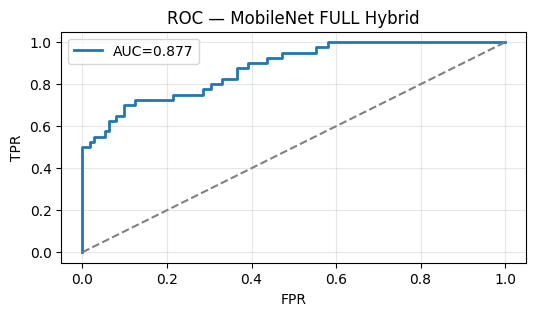

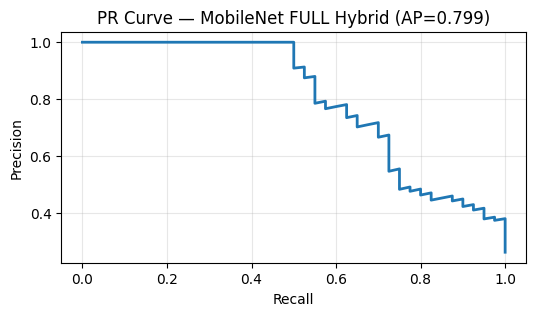

In [9]:
X_classical = X_classical_df.drop(columns=["path","label"])
imputer = SimpleImputer(strategy="median")
X_classical = imputer.fit_transform(X_classical)

deep_all = np.hstack([FH_mat, CH_mat, AB_mat])
X_full = np.hstack([X_classical, deep_all])
y = X_classical_df["label"].astype(int).values

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(svm, X_full, y, cv=cv, scoring="roc_auc")
print("MobileNet FULL Hybrid CV AUC:", cv_auc, "Mean:", cv_auc.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

svm.fit(X_train, y_train)
prob_full = svm.predict_proba(X_test)[:,1]
pred_full = (prob_full >= 0.5).astype(int)

fpr, tpr, thr = roc_curve(y_test, prob_full)
auc_full = auc(fpr, tpr)
print("MobileNet FULL Hybrid Test AUC:", auc_full)
print(classification_report(y_test, pred_full, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_full))

plt.figure(figsize=(6,3))
plt.plot(fpr, tpr, label=f"AUC={auc_full:.3f}", linewidth=2)
plt.plot([0,1],[0,1],'--', color='gray')
plt.title("ROC — MobileNet FULL Hybrid")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

prec, rec, _ = precision_recall_curve(y_test, prob_full)
ap = average_precision_score(y_test, prob_full)
plt.figure(figsize=(6,3))
plt.plot(rec, prec, linewidth=2)
plt.title(f"PR Curve — MobileNet FULL Hybrid (AP={ap:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.grid(alpha=0.3)
plt.show()

**MobileNet FULL Hybrid**
* CV AUC mean: 0.8797
* Test AUC: 0.8768
* Accuracy: 0.836

Confusion:

[[101,11],

[14,26]]

**PCA sweep (64/128/256) + plots**

In [10]:
dims = [64, 128, 256]
res = []

for d in dims:
    pca = PCA(n_components=d, random_state=42)
    deep_pca = pca.fit_transform(deep_all)
    X_pca = np.hstack([X_classical, deep_pca])

    cv_auc = cross_val_score(svm, X_pca, y, cv=cv, scoring="roc_auc")
    res.append((d, pca.explained_variance_ratio_.sum(), cv_auc.mean()))
    print(f"PCA={d} | Explained={pca.explained_variance_ratio_.sum():.3f} | CV AUC mean={cv_auc.mean():.3f}")

res_df = pd.DataFrame(res, columns=["pca_dim","explained_var_sum","cv_auc_mean"])
res_df

PCA=64 | Explained=0.486 | CV AUC mean=0.857
PCA=128 | Explained=0.635 | CV AUC mean=0.865
PCA=256 | Explained=0.799 | CV AUC mean=0.848


,pca_dim,explained_var_sum,cv_auc_mean
0,64,0.486047,0.856830
1,128,0.634991,0.865312
2,256,0.798535,0.848125


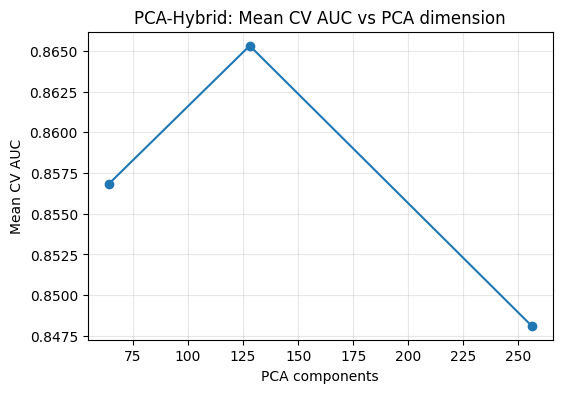

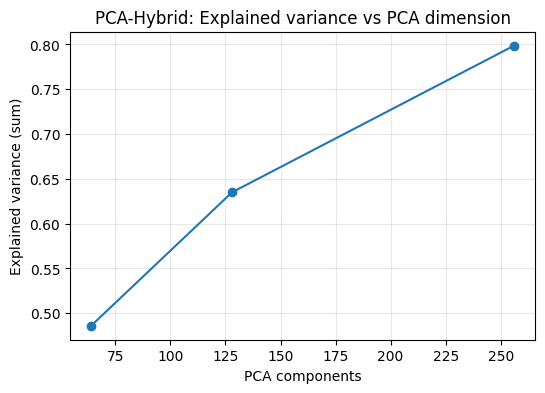

In [11]:
plt.figure(figsize=(6,4))
plt.plot(res_df["pca_dim"], res_df["cv_auc_mean"], marker="o")
plt.title("PCA-Hybrid: Mean CV AUC vs PCA dimension")
plt.xlabel("PCA components"); plt.ylabel("Mean CV AUC")
plt.grid(alpha=0.3); plt.show()

plt.figure(figsize=(6,4))
plt.plot(res_df["pca_dim"], res_df["explained_var_sum"], marker="o")
plt.title("PCA-Hybrid: Explained variance vs PCA dimension")
plt.xlabel("PCA components"); plt.ylabel("Explained variance (sum)")
plt.grid(alpha=0.3); plt.show()

**Best PCA → Test eval + Youden threshold + confusion matrix**

Best PCA dim: 128
MobileNet PCA-Hybrid Test AUC: 0.8702008928571429
              precision    recall  f1-score   support

           0      0.858     0.920     0.888       112
           1      0.719     0.575     0.639        40

    accuracy                          0.829       152
   macro avg      0.789     0.747     0.763       152
weighted avg      0.822     0.829     0.822       152

Confusion Matrix:
 [[103   9]
 [ 17  23]]
Best Threshold (Youden J): 0.19794888772378808 | TPR: 0.875 | FPR: 0.2857142857142857

=== Report @ Youden Threshold (PCA-Hybrid) ===
              precision    recall  f1-score   support

           0      0.941     0.714     0.812       112
           1      0.522     0.875     0.654        40

    accuracy                          0.757       152
   macro avg      0.732     0.795     0.733       152
weighted avg      0.831     0.757     0.771       152

Confusion Matrix:
 [[80 32]
 [ 5 35]]


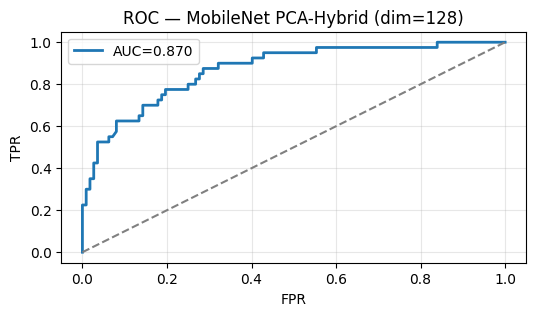

In [13]:
best_dim = int(res_df.sort_values("cv_auc_mean", ascending=False).iloc[0]["pca_dim"])
print("Best PCA dim:", best_dim)

pca_best = PCA(n_components=best_dim, random_state=42)
deep_pca = pca_best.fit_transform(deep_all)
X_best = np.hstack([X_classical, deep_pca])

X_train, X_test, y_train, y_test = train_test_split(
    X_best, y, test_size=0.2, random_state=42, stratify=y
)

svm.fit(X_train, y_train)
prob = svm.predict_proba(X_test)[:,1]
pred = (prob >= 0.5).astype(int)

fpr, tpr, thr = roc_curve(y_test, prob)
auc_best = auc(fpr, tpr)
print("MobileNet PCA-Hybrid Test AUC:", auc_best)
print(classification_report(y_test, pred, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

# Youden threshold
j = tpr - fpr
idx = np.argmax(j)
youden_thr = thr[idx]
print("Best Threshold (Youden J):", youden_thr, "| TPR:", tpr[idx], "| FPR:", fpr[idx])

pred_y = (prob >= youden_thr).astype(int)
print("\n=== Report @ Youden Threshold (PCA-Hybrid) ===")
print(classification_report(y_test, pred_y, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_y))

plt.figure(figsize=(6,3))
plt.plot(fpr, tpr, label=f"AUC={auc_best:.3f}", linewidth=2)
plt.plot([0,1],[0,1],'--', color='gray')
plt.title(f"ROC — MobileNet PCA-Hybrid (dim={best_dim})")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**MobileNet PCA-Hybrid (best dim=128)**
* CV AUC mean: 0.865
* Test AUC: 0.8702
* Brier: 0.121 (moderate)

Youden thr=0.198 → Recall 0.875 But FPR 0.286 (false positive Increase)

Confusion @ Youden:

[[80,32],[5,35]]

**Calibration + Brier + Probability hist (best PCA)**

PCA-Hybrid Brier Score: 0.12095921288791814


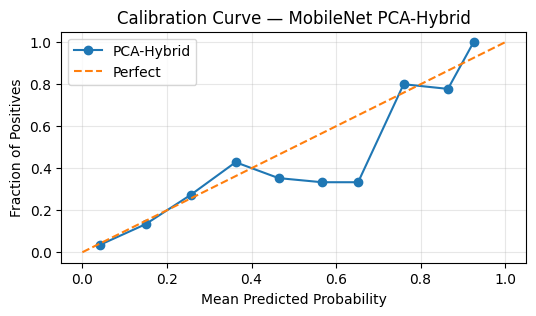

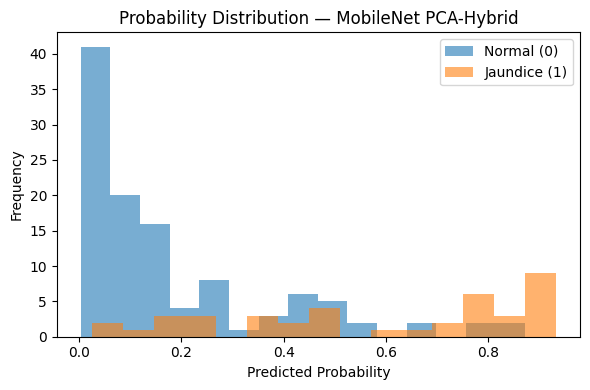

In [15]:
brier = brier_score_loss(y_test, prob)
print("PCA-Hybrid Brier Score:", brier)

frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)
plt.figure(figsize=(6,3))
plt.plot(mean_pred, frac_pos, "o-", label="PCA-Hybrid")
plt.plot([0,1],[0,1],"--", label="Perfect")
plt.title("Calibration Curve — MobileNet PCA-Hybrid")
plt.xlabel("Mean Predicted Probability"); plt.ylabel("Fraction of Positives")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(prob[y_test==0], bins=15, alpha=0.6, label="Normal (0)")
plt.hist(prob[y_test==1], bins=15, alpha=0.6, label="Jaundice (1)")
plt.title("Probability Distribution — MobileNet PCA-Hybrid")
plt.xlabel("Predicted Probability"); plt.ylabel("Frequency")
plt.legend(); plt.tight_layout()
plt.show()

**ROC + AUC**

Test AUC: 0.8702008928571429


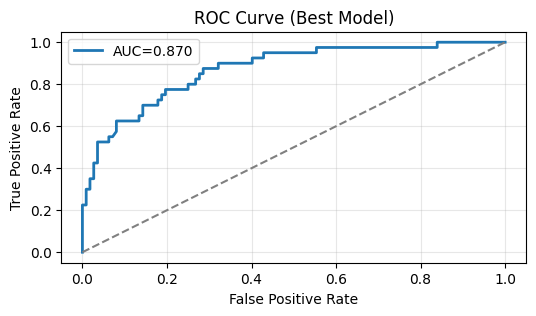

In [17]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thr = roc_curve(y_test, prob)
roc_auc = auc(fpr, tpr)
print("Test AUC:", roc_auc)

plt.figure(figsize=(6,3))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Best Model)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**PR Curve + AP**

Average Precision (AP): 0.7529301985536249


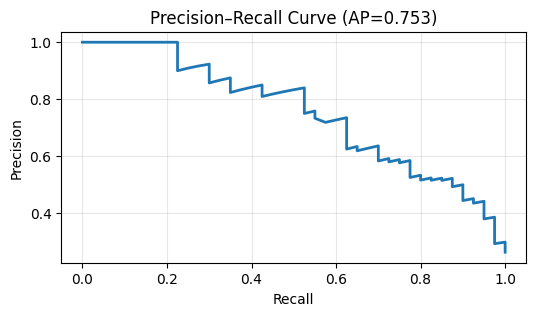

In [19]:
from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, _ = precision_recall_curve(y_test, prob)
ap = average_precision_score(y_test, prob)
print("Average Precision (AP):", ap)

plt.figure(figsize=(6,3))
plt.plot(rec, prec, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (AP={ap:.3f})")
plt.grid(alpha=0.3)
plt.show()

**Calibration curve + Brier Score**

Brier Score: 0.12095921288791814


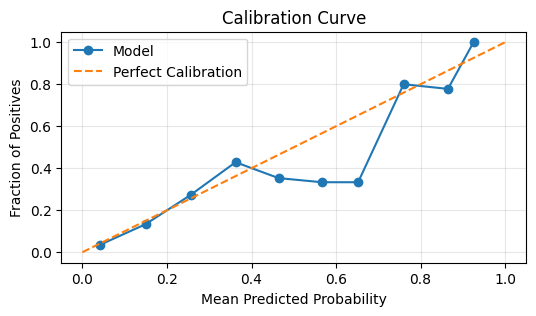

In [20]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, prob)
print("Brier Score:", brier)

frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10)

plt.figure(figsize=(6,3))
plt.plot(mean_pred, frac_pos, "o-", label="Model")
plt.plot([0,1],[0,1], "--", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Probability Distribution Histogram**

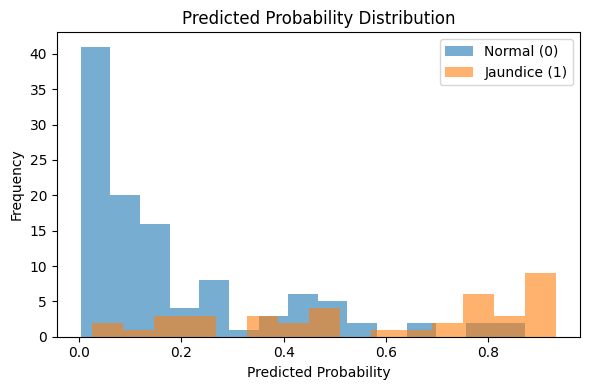

In [21]:
import numpy as np

plt.figure(figsize=(6,4))
plt.hist(prob[y_test==0], bins=15, alpha=0.6, label="Normal (0)")
plt.hist(prob[y_test==1], bins=15, alpha=0.6, label="Jaundice (1)")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Predicted Probability Distribution")
plt.legend()
plt.tight_layout()
plt.show()

**Bootstrap AUC 95% CI + Histogram**

Bootstrap AUC: 100%|██████████| 2000/2000 [00:05<00:00, 381.21it/s]


Original AUC: 0.8702008928571429
95% CI for AUC: [0.8041, 0.9290]


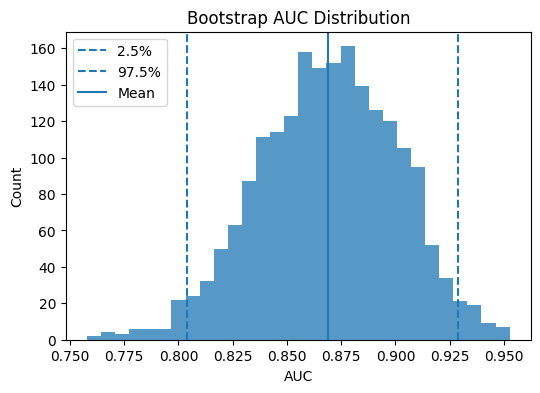

In [22]:
import numpy as np
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

n_boot = 2000
rng = np.random.RandomState(42)
boot = []

y_true = y_test
y_score = prob

for _ in tqdm(range(n_boot), desc="Bootstrap AUC"):
    idx = rng.randint(0, len(y_score), len(y_score))
    if len(np.unique(y_true[idx])) < 2:
        continue
    boot.append(roc_auc_score(y_true[idx], y_score[idx]))

boot = np.array(boot)
low, high = np.percentile(boot, 2.5), np.percentile(boot, 97.5)

print("Original AUC:", roc_auc_score(y_true, y_score))
print("95% CI for AUC: [{:.4f}, {:.4f}]".format(low, high))

plt.figure(figsize=(6,4))
plt.hist(boot, bins=30, alpha=0.75)
plt.axvline(low, linestyle="--", label="2.5%")
plt.axvline(high, linestyle="--", label="97.5%")
plt.axvline(np.mean(boot), label="Mean")
plt.title("Bootstrap AUC Distribution")
plt.xlabel("AUC")
plt.ylabel("Count")
plt.legend()
plt.show()

| Model                      | Test AUC | CV AUC mean | Brier | Youden Recall | Comment           |
| -------------------------- | -------: | ----------: | ----: | ------------: | ----------------- |
| MobileNet FULL Hybrid      |    0.877 |       0.880 |     — |             — | faster but weaker |
| MobileNet PCA-Hybrid (128) |    0.870 |       0.865 | 0.121 |         0.875 | more FP           |


**EfficientNet (previous best)**

Full Hybrid (EffNet embeddings)
* CV AUC: 0.910
* Test AUC: 0.923
* Brier: 0.083 (excellent)

Youden thr=0.424 → Confusion: [[105,7],[8,32]] (FPR very low)
* PCA-Hybrid (EffNet PCA=128)
* Test AUC: 0.918
* Brier: 0.094

Youden thr=0.259 → Confusion: [[92,20],[4,36]]


**Final Decision**

✅ In terms of accuracy/clinical balance:

EfficientNet PCA-Hybrid (128) > MobileNet PCA-Hybrid

Reasons:

Higher AUC (0.918 vs 0.870)

Better calibration (Brier 0.094 vs 0.121)

Lower FPR and stable at screening threshold

✅ In terms of speed/real-time:

MobileNet faster, but performance drop substantial.